In [42]:
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image


# paths (adjust if needed)
orig_path = 'images_fy/original_img.png'
tgt_path = 'images_fy/target_img.png'

# load images and force RGB so arrays have 3 channels
original_img = Image.open(orig_path).convert('RGB')
target_img = Image.open(tgt_path).convert('RGB')

# convert to numpy arrays
o_img_array = np.array(original_img)
t_img_array = np.array(target_img)

# print shapes only
print('original shape:', o_img_array.shape)
print('target shape:', t_img_array.shape)

# create black image with same shape and uint8 dtype
#black_image = np.zeros(o_img_array.shape, dtype=np.uint8)

# resize target to original size using PIL (note: resize takes (width, height))




In [43]:
def sort_target_onto_original_dont_use(target_image, original_image):
    if target_image.shape!=original_image.shape:
        target_image = np.array(
            target_img.resize((original_image.shape[1], original_image.shape[0]), Image.BILINEAR)
            )
    # put all pixels in orignal image into an array of (r,g,b)
    o_pixels = list(original_image.reshape(-1, 3))
    print('original pixels shape:', len(o_pixels))
    print('original pixels sample:', o_pixels[:5])
    new_image = np.zeros(original_image.shape, dtype=np.uint8)

    # go through target image (can also spiral)
    for x in range(target_image.shape[0]):
        for y in range(target_image.shape[1]):
            new_image[x][y] = o_pixels.pop(match_closest_pixel_dont_use(target_image[x][y], o_pixels))

    return new_image

def match_closest_pixel_dont_use(pixel, pixel_list: list):
    min_distance = np.inf
    for i in range(0,len(pixel_list)):
        distance = np.sqrt(np.sum(np.square(pixel_list[i] - pixel)))
        if distance < min_distance:
            min_distance = distance
            smallest_pixel_index = i
    return smallest_pixel_index


#sort_target_onto_original(t_img_array, o_img_array)

In [44]:
def downscale_images(original_image: Image.Image,
                     target_image: Image.Image,
                     max_dim: int = None,
                     scale: float = None,
                     resample=Image.LANCZOS):
    """
    Resize both images to the same downscaled size.
    - Provide `scale` (float < 1) to scale by that factor.
    - Or provide `max_dim` (int) to make the longest side equal to max_dim (keeps aspect ratio).
    Returns: (resized_original_pil, resized_target_pil, resized_original_np, resized_target_np)
    """
    # ensure inputs are PIL Images
    if not isinstance(original_image, Image.Image) or not isinstance(target_image, Image.Image):
        raise TypeError('Inputs must be PIL.Image.Image objects (call .convert(\"RGB\") when loading).')

    # choose new size
    if scale is None and max_dim is None:
        # no downscale requested, return originals
        return original_image, target_image, np.array(original_image), np.array(target_image)

    if scale is not None:
        new_w = max(1, int(original_image.width * scale))
        new_h = max(1, int(original_image.height * scale))
    else:
        factor = min(max_dim / max(original_image.width, original_image.height), 1.0)
        new_w = max(1, int(original_image.width * factor))
        new_h = max(1, int(original_image.height * factor))

    resized_original = original_image.resize((new_w, new_h), resample)
    # resize target to the same size so arrays match shape
    resized_target = target_image.resize((new_w, new_h), resample)

    return resized_original, resized_target, np.array(resized_original), np.array(resized_target)

# Example usage (in your notebook where you already created PIL images `original_img` and `target_img`):
# resized_o, resized_t, o_arr, t_arr = downscale_images(original_img, target_img, max_dim=256)
# Then pass `o_arr`, `t_arr` into sort_target_onto_original(...) or other processing.

In [45]:
# python

def sort_target_onto_original(target_image: np.ndarray,
                              original_image: np.ndarray,
                              method: str = 'sort'):
    """
    Map original image pixels onto the target layout quickly.

    - `target_image`, `original_image`: numpy arrays shape (H, W, 3), dtype uint8.
    - `method`: 'sort' (lexicographic RGB) or 'luma' (sort by luminance then chroma).
    Returns: new_image numpy array (H, W, 3), dtype uint8.
    """

    if target_image.shape != original_image.shape:
        raise ValueError('target_image and original_image must have the same shape')

    H, W, C = original_image.shape
    if C != 3:
        raise ValueError('images must have 3 channels (RGB)')

    flat_o = original_image.reshape(-1, 3).astype(np.uint8)
    flat_t = target_image.reshape(-1, 3).astype(np.uint8)
    n = flat_o.shape[0]

    if method == 'sort':
        # lexicographic RGB key (fast and stable)
        keys_o = (flat_o[:, 0].astype(np.uint32) << 16) | (flat_o[:, 1].astype(np.uint32) << 8) | flat_o[:, 2].astype(np.uint32)
        keys_t = (flat_t[:, 0].astype(np.uint32) << 16) | (flat_t[:, 1].astype(np.uint32) << 8) | flat_t[:, 2].astype(np.uint32)
        o_order = np.argsort(keys_o, kind='stable')
        t_order = np.argsort(keys_t, kind='stable')

    elif method == 'luma':
        # perceptual-ish ordering: sort by luminance then by chroma magnitude
        # luminance using Rec. 601 coefficients
        luma_o = (0.299 * flat_o[:, 0] + 0.587 * flat_o[:, 1] + 0.114 * flat_o[:, 2]).astype(np.float32)
        luma_t = (0.299 * flat_t[:, 0] + 0.587 * flat_t[:, 1] + 0.114 * flat_t[:, 2]).astype(np.float32)
        chroma_o = np.linalg.norm(flat_o.astype(np.float32) - luma_o[:, None], axis=1)
        chroma_t = np.linalg.norm(flat_t.astype(np.float32) - luma_t[:, None], axis=1)
        o_order = np.lexsort((chroma_o, luma_o))
        t_order = np.lexsort((chroma_t, luma_t))

    else:
        raise ValueError(r"method must be one of: 'sort', 'luma'")

    # assign: the i-th smallest original pixel goes to the i-th smallest target pixel
    out_flat = np.empty_like(flat_o)
    out_flat[t_order] = flat_o[o_order]

    new_image = out_flat.reshape(H, W, 3)
    return new_image

# Example usage (in your notebook):
# new_img = sort_target_onto_original(t_img_array, o_img_array, method='luma')
# plt.imshow(new_img); plt.axis('off')

original shape: (575, 862, 3)
target shape: (1472, 1000, 3)


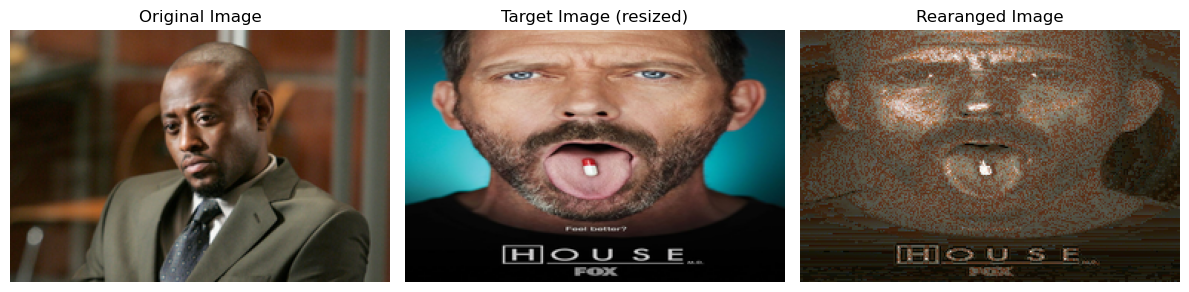

In [50]:
# paths (adjust if needed)
orig_path = 'images_fy/original_img1.png'
tgt_path = 'images_fy/target_img1.png'

# load images and force RGB so arrays have 3 channels
original_img = Image.open(orig_path).convert('RGB')
target_img = Image.open(tgt_path).convert('RGB')

# convert to numpy arrays
o_img_array = np.array(original_img)
t_img_array = np.array(target_img)

# print shapes only
print('original shape:', o_img_array.shape)
print('target shape:', t_img_array.shape)

# create black image with same shape and uint8 dtype
#black_image = np.zeros(o_img_array.shape, dtype=np.uint8)

# resize target to original size using PIL (note: resize takes (width, height))
# call downscale_images and unpack in the correct order:
o_resized_pil, t_resized_pil, o_img_array, t_img_array = downscale_images(
    original_img,
    target_img,
    max_dim=256
)

# use the resized arrays (no extra resize using the original globals)
resized_target_img = t_img_array
#black_image = np.zeros(o_img_array.shape, dtype=np.uint8)
black_image = sort_target_onto_original(t_img_array, o_img_array)

# show images
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.title('Original Image')
plt.imshow(o_img_array)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Target Image (resized)')
plt.imshow(resized_target_img)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Rearanged Image')
plt.imshow(black_image)
plt.axis('off')

plt.tight_layout()
plt.show()